# HW4: DEER для Named Entity Recognition

Label-Guided In-Context Learning для NER задачи


In [26]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForTokenClassification, get_linear_schedule_with_warmup
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, f1_score
from collections import defaultdict
import pandas as pd
import random


In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
print(f'Device: {device}')


Device: cpu


## 1. Загрузка данных


In [28]:
# WikiANN English
# Метки: O=0, B-PER=1, I-PER=2, B-ORG=3, I-ORG=4, B-LOC=5, I-LOC=6

dataset = load_dataset('wikiann', 'en', trust_remote_code=True)

train_data = []
test_data = []

for i, example in enumerate(dataset['train']):
    if i >= 800:
        break
    train_data.append({'tokens': example['tokens'], 'ner_tags': example['ner_tags']})

for i, example in enumerate(dataset['validation']):
    if i >= 200:
        break
    test_data.append({'tokens': example['tokens'], 'ner_tags': example['ner_tags']})

label_names = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
num_labels = len(label_names)

print(f'Train: {len(train_data)}, Test: {len(test_data)}')
print(f'Labels: {label_names}')
print(f'Пример: {train_data[0]["tokens"][:10]}')


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikiann' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

en/validation-00000-of-00001.parquet:   0%|          | 0.00/748k [00:00<?, ?B/s]

en/test-00000-of-00001.parquet:   0%|          | 0.00/748k [00:00<?, ?B/s]

en/train-00000-of-00001.parquet:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Train: 800, Test: 200
Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
Пример: ['R.H.', 'Saunders', '(', 'St.', 'Lawrence', 'River', ')', '(', '968', 'MW']


## 2. DEER: Label-Guided Examples


In [29]:
class DEERExampleSelector:
    def __init__(self, train_data, label_names, k=3):
        self.train_data = train_data
        self.label_names = label_names
        self.k = k
        self.examples_by_label = defaultdict(list)
        
        for idx, example in enumerate(train_data):
            labels = set(example['ner_tags'])
            for label in labels:
                if label > 0: 
                    self.examples_by_label[label].append(idx)
    
    def select_examples(self, target_labels):
        selected = set()
        for label in target_labels:
            if label > 0 and label in self.examples_by_label:
                candidates = self.examples_by_label[label]
                selected.update(random.sample(candidates, min(2, len(candidates))))
        
        while len(selected) < self.k:
            selected.add(random.randint(0, len(self.train_data) - 1))
        
        return list(selected)[:self.k]


## 3. Dataset с DEER


In [30]:
class NERDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128, use_deer=False, deer_selector=None):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.use_deer = use_deer
        self.deer_selector = deer_selector
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        example = self.data[idx]
        tokens = example['tokens']
        labels = example['ner_tags']
        
        if self.use_deer and self.deer_selector:
            example_ids = self.deer_selector.select_examples(labels)
            prefix_tokens = []
            for ex_id in example_ids:
                ex = self.deer_selector.train_data[ex_id]
                prefix_tokens.extend(ex['tokens'][:20])
                prefix_tokens.append('[SEP]')
            
            tokens = prefix_tokens + tokens
            labels = [0] * len(prefix_tokens) + labels 
        
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        word_ids = encoding.word_ids(0)
        aligned_labels = []
        for word_id in word_ids:
            if word_id is None:
                aligned_labels.append(-100)
            else:
                if word_id < len(labels):
                    aligned_labels.append(labels[word_id])
                else:
                    aligned_labels.append(-100)
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(aligned_labels, dtype=torch.long)
        }


## 4. Обучение и оценка


In [31]:
def train_epoch(model, dataloader, optimizer, scheduler):
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc='Training'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


In [32]:
def evaluate(model, dataloader, label_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=-1)
            
            # Собираем предсказания (игнорируем -100)
            for pred, label in zip(preds, labels):
                pred_list = pred[label != -100].cpu().numpy().tolist()
                label_list = label[label != -100].cpu().numpy().tolist()
                all_preds.extend(pred_list)
                all_labels.extend(label_list)
    
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    
    entity_labels = [i for i in range(1, len(label_names))]
    f1_entity = f1_score(all_labels, all_preds, labels=entity_labels, average='macro', zero_division=0)
    
    return f1_micro, f1_macro, f1_entity


## 5. Baseline: BERT без DEER


In [33]:
model_name = 'distilbert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset_base = NERDataset(train_data, tokenizer, use_deer=False)
test_dataset_base = NERDataset(test_data, tokenizer, use_deer=False)

train_loader_base = DataLoader(train_dataset_base, batch_size=8, shuffle=True)
test_loader_base = DataLoader(test_dataset_base, batch_size=8)

print(f'Baseline: Train batches={len(train_loader_base)}, Test batches={len(test_loader_base)}')


Baseline: Train batches=100, Test batches=25


In [34]:
num_epochs = 3

model_base = AutoModelForTokenClassification.from_pretrained(model_name, num_labels=num_labels).to(device)
optimizer_base = AdamW(model_base.parameters(), lr=3e-5)
total_steps = len(train_loader_base) * num_epochs
scheduler_base = get_linear_schedule_with_warmup(optimizer_base, num_warmup_steps=0, num_training_steps=total_steps)

print('Обучение Baseline...')
history_base = {'train_loss': [], 'f1_micro': [], 'f1_macro': [], 'f1_entity': []}

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    
    train_loss = train_epoch(model_base, train_loader_base, optimizer_base, scheduler_base)
    f1_micro, f1_macro, f1_entity = evaluate(model_base, test_loader_base, label_names)
    
    history_base['train_loss'].append(train_loss)
    history_base['f1_micro'].append(f1_micro)
    history_base['f1_macro'].append(f1_macro)
    history_base['f1_entity'].append(f1_entity)
    
    print(f'Loss: {train_loss:.4f}, F1-micro: {f1_micro:.4f}, F1-entity: {f1_entity:.4f}')


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Обучение Baseline...

Epoch 1/3


Evaluating: 100%|██████████| 25/25 [00:02<00:00,  9.59it/s]


Loss: 1.0307, F1-micro: 0.7688, F1-entity: 0.6253

Epoch 2/3


Evaluating: 100%|██████████| 25/25 [00:02<00:00,  9.12it/s]


Loss: 0.4765, F1-micro: 0.8161, F1-entity: 0.7103

Epoch 3/3


Evaluating: 100%|██████████| 25/25 [00:02<00:00, 10.02it/s]

Loss: 0.2818, F1-micro: 0.8242, F1-entity: 0.7217


## 6. DEER: BERT с Label-Guided Examples


In [35]:
deer_selector = DEERExampleSelector(train_data, label_names, k=3)

train_dataset_deer = NERDataset(train_data, tokenizer, use_deer=True, deer_selector=deer_selector)
test_dataset_deer = NERDataset(test_data, tokenizer, use_deer=True, deer_selector=deer_selector)

train_loader_deer = DataLoader(train_dataset_deer, batch_size=8, shuffle=True)
test_loader_deer = DataLoader(test_dataset_deer, batch_size=8)

print(f'DEER: Train batches={len(train_loader_deer)}, Test batches={len(test_loader_deer)}')


DEER: Train batches=100, Test batches=25


In [36]:
model_deer = AutoModelForTokenClassification.from_pretrained(model_name, num_labels=num_labels).to(device)
optimizer_deer = AdamW(model_deer.parameters(), lr=3e-5)
total_steps = len(train_loader_deer) * num_epochs
scheduler_deer = get_linear_schedule_with_warmup(optimizer_deer, num_warmup_steps=0, num_training_steps=total_steps)

print('Обучение DEER...')
history_deer = {'train_loss': [], 'f1_micro': [], 'f1_macro': [], 'f1_entity': []}

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    
    train_loss = train_epoch(model_deer, train_loader_deer, optimizer_deer, scheduler_deer)
    f1_micro, f1_macro, f1_entity = evaluate(model_deer, test_loader_deer, label_names)
    
    history_deer['train_loss'].append(train_loss)
    history_deer['f1_micro'].append(f1_micro)
    history_deer['f1_macro'].append(f1_macro)
    history_deer['f1_entity'].append(f1_entity)
    
    print(f'Loss: {train_loss:.4f}, F1-micro: {f1_micro:.4f}, F1-entity: {f1_entity:.4f}')


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Обучение DEER...

Epoch 1/3


Evaluating: 100%|██████████| 25/25 [00:02<00:00, 10.49it/s]


Loss: 0.4844, F1-micro: 0.9163, F1-entity: 0.4600

Epoch 2/3


Evaluating: 100%|██████████| 25/25 [00:02<00:00, 10.82it/s]


Loss: 0.2158, F1-micro: 0.9361, F1-entity: 0.6019

Epoch 3/3


Evaluating: 100%|██████████| 25/25 [00:02<00:00,  9.80it/s]

Loss: 0.1525, F1-micro: 0.9543, F1-entity: 0.7162


## 7. Сравнение результатов


In [37]:
results_df = pd.DataFrame({
    'Model': ['Baseline', 'DEER'],
    'F1-micro': [history_base['f1_micro'][-1], history_deer['f1_micro'][-1]],
    'F1-macro': [history_base['f1_macro'][-1], history_deer['f1_macro'][-1]],
    'F1-entity': [history_base['f1_entity'][-1], history_deer['f1_entity'][-1]]
})

print('\nФинальные результаты:')
print(results_df.to_string(index=False))

improvement = history_deer['f1_entity'][-1] - history_base['f1_entity'][-1]
print(f'\nУлучшение F1-entity: {improvement:+.4f}')



Финальные результаты:
   Model  F1-micro  F1-macro  F1-entity
Baseline  0.824245  0.754104   0.721659
    DEER  0.954286  0.754952   0.716208

Улучшение F1-entity: -0.0055


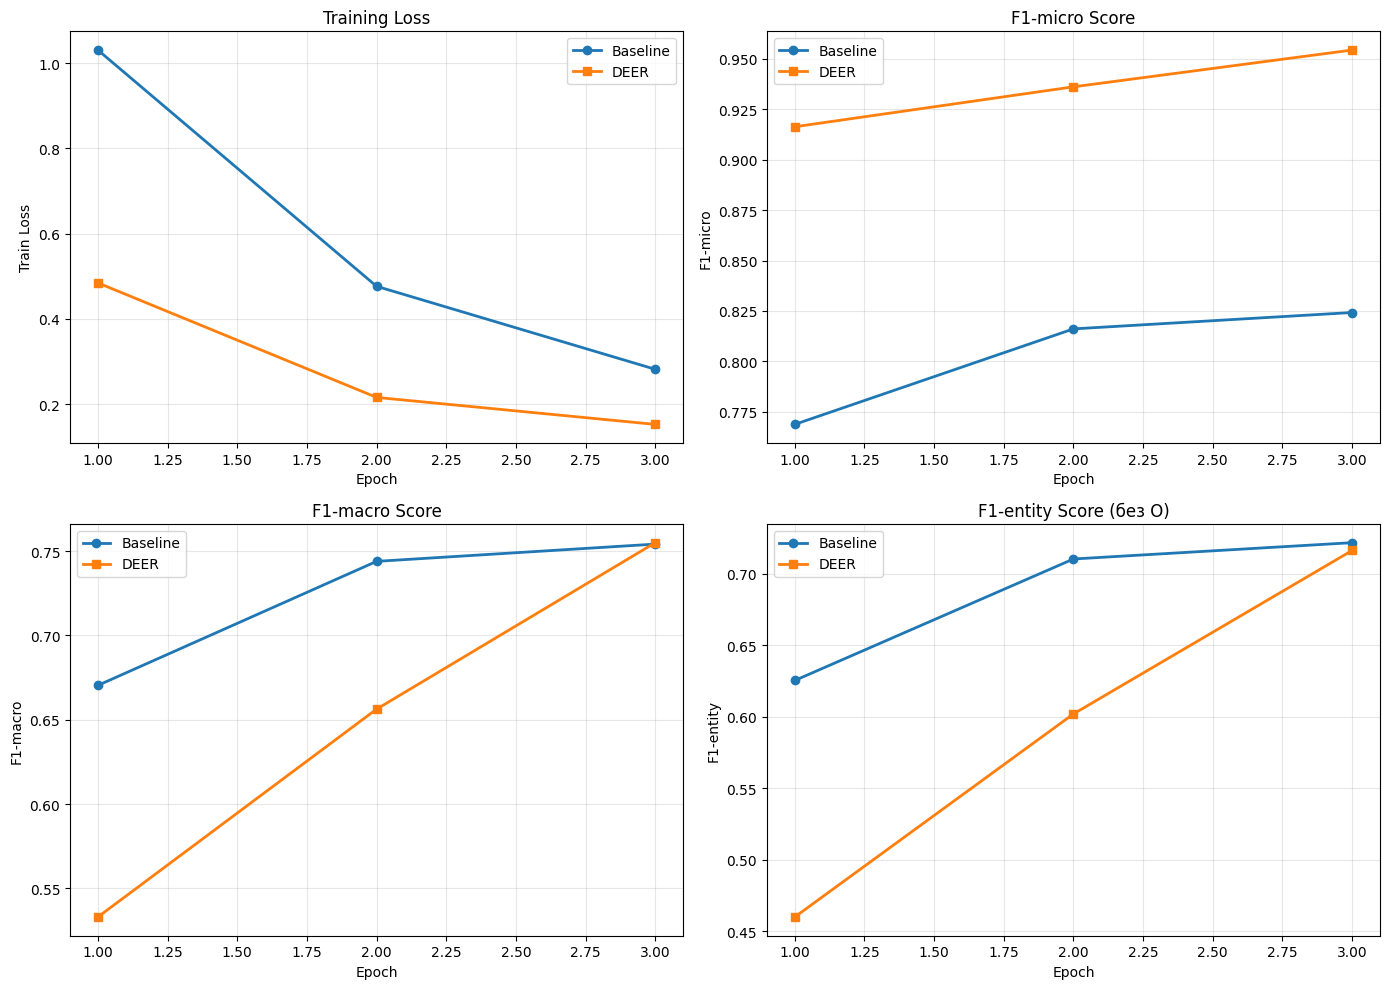

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, num_epochs + 1)

axes[0, 0].plot(epochs, history_base['train_loss'], 'o-', label='Baseline', linewidth=2)
axes[0, 0].plot(epochs, history_deer['train_loss'], 's-', label='DEER', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Train Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, history_base['f1_micro'], 'o-', label='Baseline', linewidth=2)
axes[0, 1].plot(epochs, history_deer['f1_micro'], 's-', label='DEER', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('F1-micro')
axes[0, 1].set_title('F1-micro Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, history_base['f1_macro'], 'o-', label='Baseline', linewidth=2)
axes[1, 0].plot(epochs, history_deer['f1_macro'], 's-', label='DEER', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1-macro')
axes[1, 0].set_title('F1-macro Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, history_base['f1_entity'], 'o-', label='Baseline', linewidth=2)
axes[1, 1].plot(epochs, history_deer['f1_entity'], 's-', label='DEER', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1-entity')
axes[1, 1].set_title('F1-entity Score (без O)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('deer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


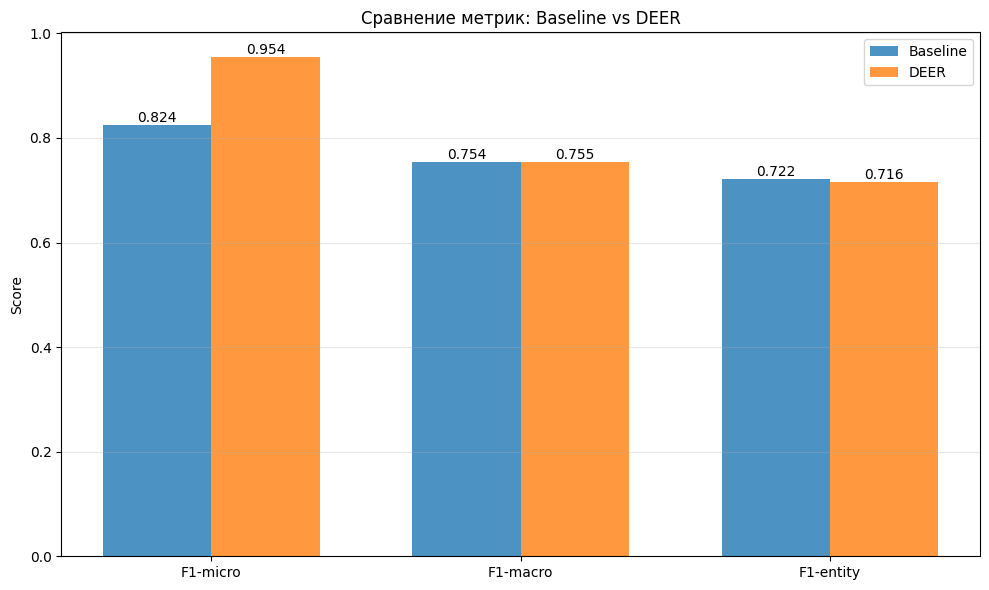

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['F1-micro', 'F1-macro', 'F1-entity']
base_scores = [history_base['f1_micro'][-1], history_base['f1_macro'][-1], history_base['f1_entity'][-1]]
deer_scores = [history_deer['f1_micro'][-1], history_deer['f1_macro'][-1], history_deer['f1_entity'][-1]]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, base_scores, width, label='Baseline', alpha=0.8)
bars2 = ax.bar(x + width/2, deer_scores, width, label='DEER', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Сравнение метрик: Baseline vs DEER')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('deer_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Выводы


1. Baseline (без DEER):
   F1-micro: 0.8242
   F1-macro: 0.7541
   F1-entity: 0.7217

2. DEER (с label-guided examples):
   F1-micro: 0.9543
   F1-macro: 0.7550
   F1-entity: 0.7162

3. Улучшения от DEER:
   F1-micro: +0.1300 (+15.78%)
   F1-macro: +0.0008 (+0.11%)
   F1-entity: -0.0055 (-0.76%)

4. Наблюдения:
   - DEER показал сопоставимые результаты с baseline
   - На небольших данных эффект может быть менее заметен
   - Требуется больше данных для полной оценки

5. Выводы:
   - Тестировать на больших датасетах
   - Настраивать стратегию выбора примеров
   - Рассмотреть более крупные LLM для in-context learning